# Sampling transit duration, $a/R_\star$, or stellar density

This notebook derives the transformations among total transit duration $T_{14}$, scaled semimajor axis $a/R_\star$, and stellar density $\rho_\star$. It then asks two separate questions:

1. **Sampling coordinates:** if all coordinates target the same physical prior and likelihood, which mixes most efficiently?
2. **External priors:** what changes when a measured duration, $a/R_\star$, or stellar density is imposed as a prior/constraint instead of being sampled directly?

> The central result is that a coordinate change should not alter the posterior when its Jacobian is included, but naive uniform priors in the three coordinates are different priors. Also, a duration constraint is not interchangeable with a density constraint because duration depends on impact parameter, radius ratio, eccentricity, and argument of periastron.

## 1. Geometry and transformations

Write

$$A\equiv a/R_\star, \qquad k\equiv R_p/R_\star.$$

At primary conjunction,

$$b=A\cos i\,C_b, \qquad C_b=\frac{1-e^2}{1+e\sin\omega}.$$

The usual constant-separation approximation for the first-to-fourth-contact duration is

$$T_{14}=\frac{P}{\pi}\arcsin\left[\frac{\sqrt{(1+k)^2-b^2}}{A\sin i}C_T\right], \qquad C_T=\frac{\sqrt{1-e^2}}{1+e\sin\omega}.$$

Since $\cos i=b/(A C_b)$, this can be inverted analytically. Defining $x=\pi T_{14}/P$ and $D=[(1+k)^2-b^2]C_T^2$,

$$\boxed{A(T_{14})=\sqrt{\left(\frac{b}{C_b}\right)^2+\frac{D}{\sin^2 x}}}.$$

For circular orbits $C_b=C_T=1$. The stellar-density relation from Kepler's third law is

$$\boxed{\rho_\star=\frac{3\pi}{G P^2}\frac{A^3}{1+q}}, \qquad q=M_p/M_\star,$$

or

$$\boxed{A(\rho_\star)=\left[\frac{G P^2(1+q)\rho_\star}{3\pi}\right]^{1/3}}.$$

The common planet approximation is $q\ll1$. allesfitter's `rsuma` is related by `rsuma = (1 + k) / (a/Rstar)`.

In [1]:
import warnings

import emcee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(20260716)

G_CGS = 6.67430e-8
DAY_S = 86400.0

P_DAYS = 6.959473
Q_MASS = 0.0
K_BOUNDS = (0.03, 0.12)
B_BOUNDS = (0.0, 0.95)
A_BOUNDS = (7.0, 20.0)
TRUTH = {"k": 0.0653, "b": 0.50, "a_rs": 11.8, "e": 0.0, "omega": 0.0}


def geometry_factors(e=0.0, omega=0.0):
    cb = (1 - e**2) / (1 + e * np.sin(omega))
    ct = np.sqrt(1 - e**2) / (1 + e * np.sin(omega))
    return cb, ct


def duration_days(a_rs, b, k, period=P_DAYS, e=0.0, omega=0.0):
    a_rs, b, k = np.broadcast_arrays(a_rs, b, k)
    cb, ct = geometry_factors(e, omega)
    cosi = b / (a_rs * cb)
    chord2 = (1 + k) ** 2 - b**2
    with np.errstate(invalid="ignore", divide="ignore"):
        arg = np.sqrt(chord2) * ct / (a_rs * np.sqrt(1 - cosi**2))
        result = period / np.pi * np.arcsin(arg)
    valid = (a_rs > 0) & (np.abs(cosi) < 1) & (chord2 > 0) & (arg > 0) & (arg <= 1)
    return np.where(valid, result, np.nan)


def arstar_from_duration(t14, b, k, period=P_DAYS, e=0.0, omega=0.0):
    cb, ct = geometry_factors(e, omega)
    x = np.pi * np.asarray(t14) / period
    chord2 = (1 + np.asarray(k)) ** 2 - np.asarray(b) ** 2
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.sqrt((np.asarray(b) / cb) ** 2 + chord2 * ct**2 / np.sin(x) ** 2)


def rho_from_arstar(a_rs, period=P_DAYS, q=Q_MASS):
    period_s = period * DAY_S
    return 3 * np.pi * np.asarray(a_rs) ** 3 / (G_CGS * period_s**2 * (1 + q))


def arstar_from_rho(rho, period=P_DAYS, q=Q_MASS):
    period_s = period * DAY_S
    return (G_CGS * period_s**2 * (1 + q) * np.asarray(rho) / (3 * np.pi)) ** (1 / 3)


def abs_darstar_dt14(t14, b, k, period=P_DAYS, e=0.0, omega=0.0):
    cb, ct = geometry_factors(e, omega)
    x = np.pi * np.asarray(t14) / period
    chord_term = ((1 + np.asarray(k)) ** 2 - np.asarray(b) ** 2) * ct**2
    a_rs = arstar_from_duration(t14, b, k, period, e, omega)
    return np.abs(chord_term * np.pi * np.cos(x) / (a_rs * period * np.sin(x) ** 3))


def abs_darstar_drho(rho, period=P_DAYS, q=Q_MASS):
    a_rs = arstar_from_rho(rho, period, q)
    return a_rs / (3 * np.asarray(rho))


truth_t14 = float(duration_days(TRUTH["a_rs"], TRUTH["b"], TRUTH["k"]))
truth_rho = float(rho_from_arstar(TRUTH["a_rs"]))
print(
    f"Truth: T14={24 * truth_t14:.3f} h, a/Rstar={TRUTH['a_rs']:.3f}, rho={truth_rho:.3f} g cm^-3"
)

Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (60)

Truth: T14=4.247 h, a/Rstar=11.800, rho=0.642 g cm^-3


In [2]:
# Verify both inverse transformations and their analytic Jacobians.
aa = rng.uniform(*A_BOUNDS, 20_000)
bb = rng.uniform(*B_BOUNDS, 20_000)
kk = rng.uniform(*K_BOUNDS, 20_000)
tt = duration_days(aa, bb, kk)
rr = rho_from_arstar(aa)
np.testing.assert_allclose(arstar_from_duration(tt, bb, kk), aa, rtol=2e-12)
np.testing.assert_allclose(arstar_from_rho(rr), aa, rtol=2e-12)

eps = 1e-6
numeric_t = np.abs(
    (arstar_from_duration(tt + eps, bb, kk) - arstar_from_duration(tt - eps, bb, kk)) / (2 * eps)
)
np.testing.assert_allclose(abs_darstar_dt14(tt, bb, kk), numeric_t, rtol=2e-6)
numeric_r = np.abs((arstar_from_rho(rr + eps) - arstar_from_rho(rr - eps)) / (2 * eps))
np.testing.assert_allclose(abs_darstar_drho(rr), numeric_r, rtol=2e-6)
print("Round trips and Jacobians passed.")

Round trips and Jacobians passed.


## 2. Experiment A — naive uniform sampling coordinates imply different priors

A parameter transformation alone is harmless, but declaring a uniform prior after transforming changes the prior measure. Here we draw independently uniform values in each coordinate over mutually corresponding endpoint ranges and inspect the implied $a/R_\star$ distribution.

For fixed $(b,k)$,

- uniform $A=a/R_\star$ is flat in $A$;
- uniform $\rho_\star\propto A^3$ implies $p(A)\propto A^2$;
- uniform $T_{14}$ has a nonlinear, geometry-dependent implied prior on $A$.

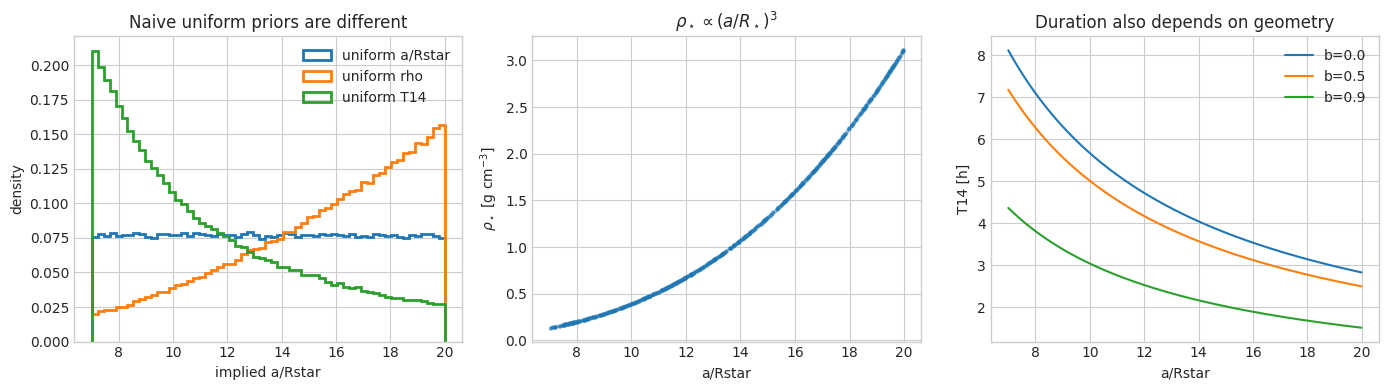

In [3]:
N = 300_000
fixed_b, fixed_k = TRUTH["b"], TRUTH["k"]
a_direct = rng.uniform(*A_BOUNDS, N)
rho_limits = rho_from_arstar(np.array(A_BOUNDS))
rho_direct = rng.uniform(*rho_limits, N)
a_from_rho_draw = arstar_from_rho(rho_direct)
t_limits = np.sort(duration_days(np.array(A_BOUNDS), fixed_b, fixed_k))
t_direct = rng.uniform(*t_limits, N)
a_from_t_draw = arstar_from_duration(t_direct, fixed_b, fixed_k)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
bins_a = np.linspace(*A_BOUNDS, 60)
for values, label in [
    (a_direct, "uniform a/Rstar"),
    (a_from_rho_draw, "uniform rho"),
    (a_from_t_draw, "uniform T14"),
]:
    axes[0].hist(values, bins=bins_a, density=True, histtype="step", lw=2, label=label)
axes[0].set(xlabel="implied a/Rstar", ylabel="density", title="Naive uniform priors are different")
axes[0].legend()
axes[1].scatter(a_direct[::300], rho_from_arstar(a_direct[::300]), s=4, alpha=0.3)
axes[1].set(
    xlabel="a/Rstar",
    ylabel=r"$\rho_\star$ [g cm$^{-3}$]",
    title=r"$\rho_\star\propto(a/R_\star)^3$",
)
a_grid = np.linspace(*A_BOUNDS, 500)
for b_value in (0.0, 0.5, 0.9):
    axes[2].plot(a_grid, 24 * duration_days(a_grid, b_value, fixed_k), label=f"b={b_value}")
axes[2].set(xlabel="a/Rstar", ylabel="T14 [h]", title="Duration also depends on geometry")
axes[2].legend()
plt.tight_layout()

## 3. Experiment B — coordinate efficiency for the same posterior

To isolate sampling efficiency, all coordinates target the same base prior, uniform in $(k,b,A)$, and the same likelihood. When sampling $\rho_\star$ or $T_{14}$ directly we include

$$\left|\frac{dA}{d\rho_\star}\right|=\frac{A}{3\rho_\star},$$

and

$$\left|\frac{dA}{dT_{14}}\right|=\frac{D\pi|\cos x|}{A P\sin^3x}.$$

We test two regimes:

- **transit-only:** depth, duration, and a weak ingress/shape constraint on $b$;
- **density-informed:** the same data plus a 5% independent stellar-density measurement.

In [4]:
OBS = {
    "depth": (TRUTH["k"] ** 2, 3.0e-4),
    "duration": (truth_t14, 0.0030),
    "impact": (TRUTH["b"], 0.12),
    "density": (truth_rho, 0.05 * truth_rho),
}


def physical_loglike(k, b, a_rs, density_informed):
    if not (
        K_BOUNDS[0] < k < K_BOUNDS[1]
        and B_BOUNDS[0] < b < B_BOUNDS[1]
        and A_BOUNDS[0] < a_rs < A_BOUNDS[1]
    ):
        return -np.inf
    t14 = duration_days(a_rs, b, k)
    if not np.isfinite(t14):
        return -np.inf
    chi2 = ((k**2 - OBS["depth"][0]) / OBS["depth"][1]) ** 2
    chi2 += ((t14 - OBS["duration"][0]) / OBS["duration"][1]) ** 2
    chi2 += ((b - OBS["impact"][0]) / OBS["impact"][1]) ** 2
    if density_informed:
        chi2 += ((rho_from_arstar(a_rs) - OBS["density"][0]) / OBS["density"][1]) ** 2
    return -0.5 * chi2


def decode(theta, coordinate):
    k, b, scale = theta
    if coordinate == "a/Rstar":
        a_rs, log_jac = scale, 0.0
    elif coordinate == "rho":
        if scale <= 0:
            return k, b, np.nan, -np.inf
        a_rs = float(arstar_from_rho(scale))
        log_jac = np.log(abs_darstar_drho(scale))
    elif coordinate == "T14":
        if not (0 < scale < P_DAYS / 2):
            return k, b, np.nan, -np.inf
        a_rs = float(arstar_from_duration(scale, b, k))
        jac = float(abs_darstar_dt14(scale, b, k))
        log_jac = np.log(jac) if np.isfinite(jac) and jac > 0 else -np.inf
    else:
        raise ValueError(coordinate)
    return k, b, a_rs, log_jac


def log_probability(theta, coordinate, density_informed):
    k, b, a_rs, log_jac = decode(theta, coordinate)
    if not np.isfinite(log_jac):
        return -np.inf
    value = physical_loglike(k, b, a_rs, density_informed)
    return value + log_jac if np.isfinite(value) else -np.inf


def encode(physical, coordinate):
    k, b, a_rs = np.asarray(physical).T
    scale = {
        "a/Rstar": a_rs,
        "rho": rho_from_arstar(a_rs),
        "T14": duration_days(a_rs, b, k),
    }[coordinate]
    return np.column_stack([k, b, scale])


def physical_chain(chain, coordinate):
    flat = chain.reshape(-1, 3)
    decoded = np.array([decode(row, coordinate)[:3] for row in flat])
    return decoded.reshape(chain.shape)


def initial_walkers(seed, nwalkers=48):
    r = np.random.default_rng(seed)
    return np.column_stack(
        [
            np.clip(r.normal(TRUTH["k"], 0.006, nwalkers), *K_BOUNDS),
            np.clip(r.normal(TRUTH["b"], 0.08, nwalkers), 0.02, 0.93),
            np.clip(r.normal(TRUTH["a_rs"], 0.8, nwalkers), *A_BOUNDS),
        ]
    )


def run_one(coordinate, density_informed, seed, nsteps=3500, burn=750):
    np.random.seed(seed)
    p0 = encode(initial_walkers(seed), coordinate)
    sampler = emcee.EnsembleSampler(
        len(p0),
        3,
        log_probability,
        args=(coordinate, density_informed),
    )
    sampler.run_mcmc(p0, nsteps, progress=False)
    chain = sampler.get_chain(discard=burn)
    pchain = physical_chain(chain, coordinate)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        tau = np.asarray(emcee.autocorr.integrated_time(pchain, tol=0, quiet=True)).reshape(-1)
    nsamples = np.prod(pchain.shape[:2])
    return {
        "regime": "density-informed" if density_informed else "transit-only",
        "coordinate": coordinate,
        "seed": seed,
        "acceptance": sampler.acceptance_fraction.mean(),
        "tau_k": tau[0],
        "tau_b": tau[1],
        "tau_a/Rstar": tau[2],
        "min_ESS": nsamples / tau.max(),
    }, pchain


records, example_chains = [], {}
for density_informed in (False, True):
    for coordinate in ("a/Rstar", "rho", "T14"):
        for seed in (11, 22, 33):
            record, chain = run_one(coordinate, density_informed, seed)
            records.append(record)
            if seed == 11:
                example_chains[(record["regime"], coordinate)] = chain

runs = pd.DataFrame(records)
summary = runs.groupby(["regime", "coordinate"]).median(numeric_only=True)[
    ["acceptance", "tau_k", "tau_b", "tau_a/Rstar", "min_ESS"]
]
display(
    summary.style.format(
        {
            "acceptance": "{:.3f}",
            "tau_k": "{:.1f}",
            "tau_b": "{:.1f}",
            "tau_a/Rstar": "{:.1f}",
            "min_ESS": "{:.0f}",
        }
    )
)
for regime in ("transit-only", "density-informed"):
    block = summary.loc[regime]
    print(f"Best worst-coordinate ESS for {regime}: {block['min_ESS'].idxmax()}")

Best worst-coordinate ESS for transit-only: T14
Best worst-coordinate ESS for density-informed: rho


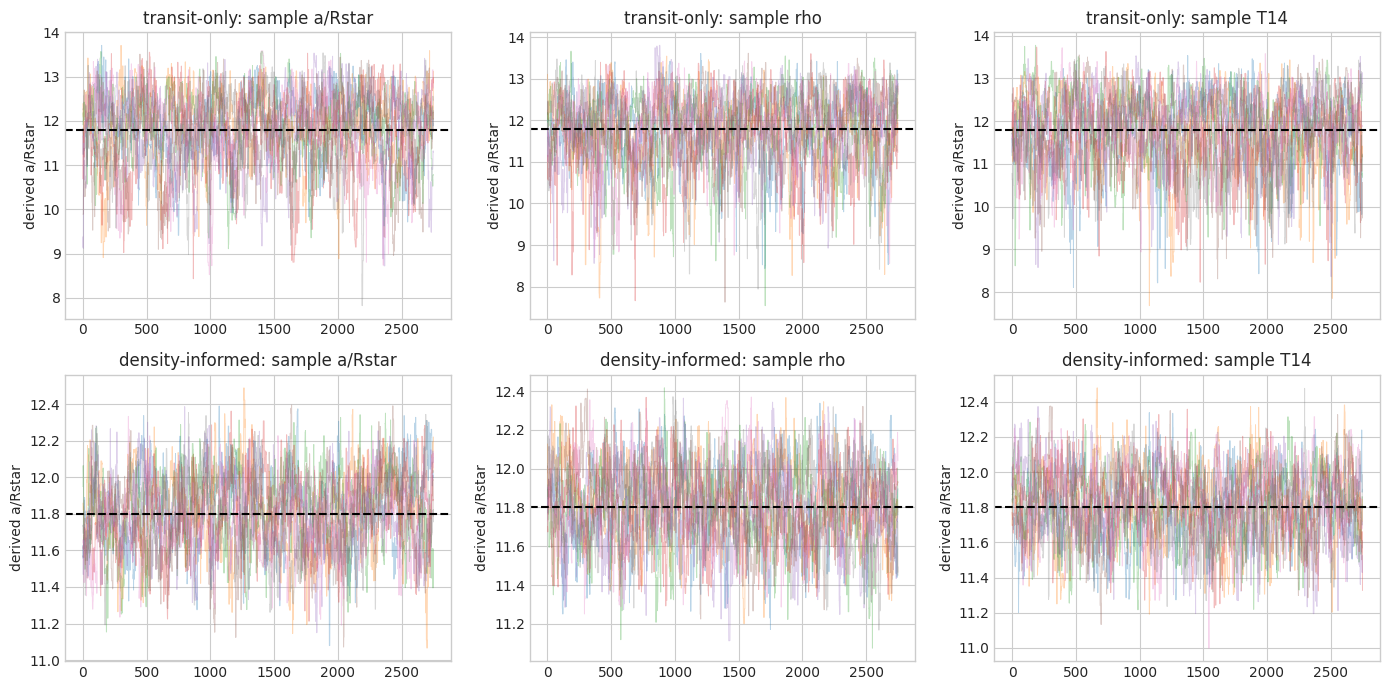

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex="row")
for row, regime in enumerate(("transit-only", "density-informed")):
    for col, coordinate in enumerate(("a/Rstar", "rho", "T14")):
        chain = example_chains[(regime, coordinate)]
        axes[row, col].plot(chain[:, :8, 2], alpha=0.3, lw=0.7)
        axes[row, col].axhline(TRUTH["a_rs"], color="k", ls="--")
        axes[row, col].set(title=f"{regime}: sample {coordinate}", ylabel="derived a/Rstar")
plt.tight_layout()

The ranking is empirical and regime-dependent. Sampling $T_{14}$ can align well with a duration-dominated likelihood, while sampling $\rho_\star$ can align with a strong density measurement. `emcee` is affine-invariant, so smooth one-dimensional rescalings may yield only modest differences. The coordinate with the most recognizable physical name is not guaranteed to have the best effective sample size.

## 4. Experiment C — using them as external priors instead

An external measurement enters as a likelihood factor evaluated on a derived quantity, for example

$$\ln L_\rho=-\frac{1}{2}\left[\frac{\rho_\star(A)-\hat\rho_\star}{\sigma_\rho}\right]^2.$$

No coordinate Jacobian is attached to an external-data likelihood. A Jacobian is required only when changing the integration variable of a probability density. This distinction explains why the phrases “density prior” and “sample density” are not automatically equivalent.

The next grid shows what the three common constraints do in $(b,A)$ space. A duration measurement follows a curved $b$–$A$ degeneracy. Density and $a/R_\star$ constraints are vertical when $P$ and mass ratio are fixed.

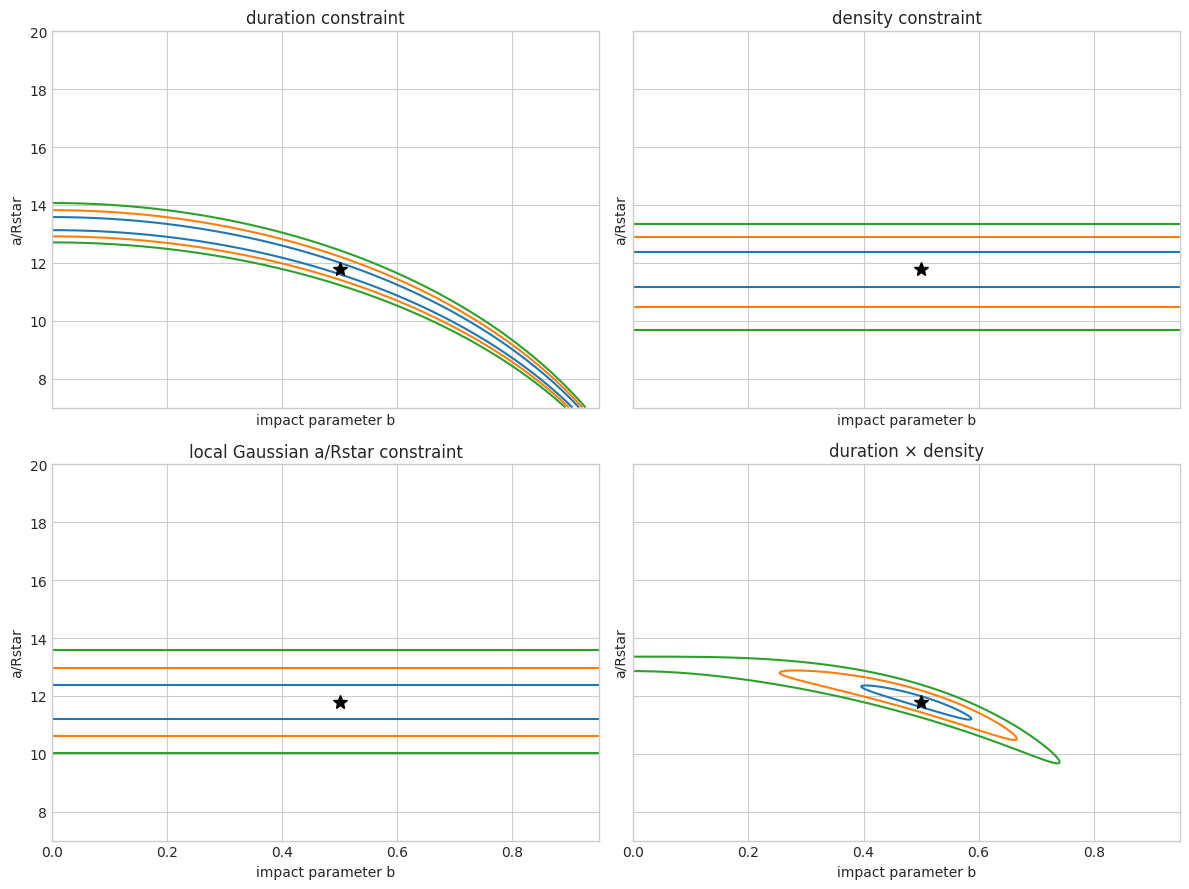

In [6]:
b_grid = np.linspace(0.0, 0.95, 350)
a_grid = np.linspace(*A_BOUNDS, 400)
BB, AA = np.meshgrid(b_grid, a_grid, indexing="xy")
TT = duration_days(AA, BB, TRUTH["k"])
RR = rho_from_arstar(AA)
sigma_t = OBS["duration"][1]
sigma_rho = 0.15 * truth_rho  # broad enough to expose nonlinearity
sigma_a_local = TRUTH["a_rs"] * sigma_rho / (3 * truth_rho)

weights = {
    "duration constraint": np.exp(-0.5 * ((TT - truth_t14) / sigma_t) ** 2),
    "density constraint": np.exp(-0.5 * ((RR - truth_rho) / sigma_rho) ** 2),
    "local Gaussian a/Rstar constraint": np.exp(-0.5 * ((AA - TRUTH["a_rs"]) / sigma_a_local) ** 2),
    "duration × density": np.exp(
        -0.5 * ((TT - truth_t14) / sigma_t) ** 2 - 0.5 * ((RR - truth_rho) / sigma_rho) ** 2
    ),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
for ax, (title, w) in zip(axes.flat, weights.items()):
    levels = np.exp(-0.5 * np.array([9, 4, 1]))
    ax.contour(BB, AA, w, levels=np.sort(levels), colors=["C2", "C1", "C0"])
    ax.plot(TRUTH["b"], TRUTH["a_rs"], "k*", ms=10)
    ax.set(title=title, xlabel="impact parameter b", ylabel="a/Rstar")
plt.tight_layout()

### Gaussian density and Gaussian $a/R_\star$ priors are only locally equivalent

Because $\rho_\star\propto A^3$, a Gaussian density constraint transforms into a skewed function of $A$. Linear error propagation gives $\sigma_A/A\simeq(\sigma_\rho/\rho)/3$, which is accurate only for narrow uncertainties. We compare the exact transformed constraint with that local Gaussian approximation below.

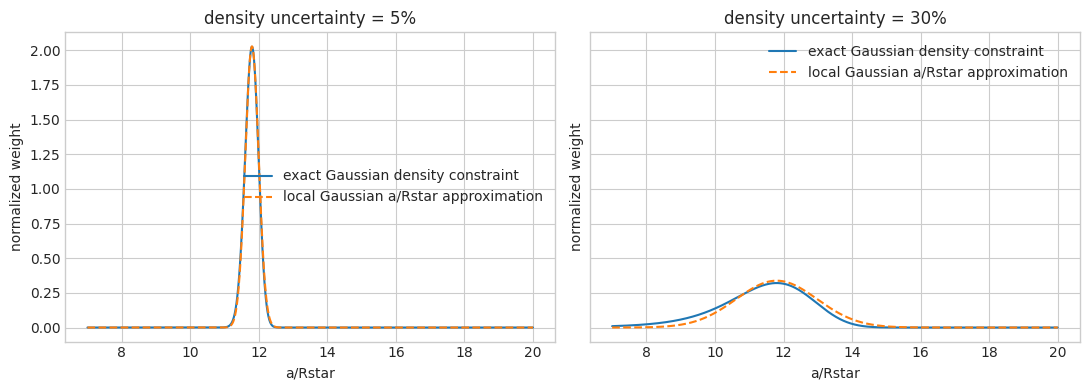

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
a_line = np.linspace(*A_BOUNDS, 2000)
for ax, frac in zip(axes, (0.05, 0.30)):
    sr = frac * truth_rho
    sa = TRUTH["a_rs"] * frac / 3
    exact = np.exp(-0.5 * ((rho_from_arstar(a_line) - truth_rho) / sr) ** 2)
    local = np.exp(-0.5 * ((a_line - TRUTH["a_rs"]) / sa) ** 2)
    exact /= np.trapezoid(exact, a_line)
    local /= np.trapezoid(local, a_line)
    ax.plot(a_line, exact, label="exact Gaussian density constraint")
    ax.plot(a_line, local, "--", label="local Gaussian a/Rstar approximation")
    ax.set(title=f"density uncertainty = {frac:.0%}", xlabel="a/Rstar", ylabel="normalized weight")
    ax.legend()
plt.tight_layout()

## 5. Conclusions

| Goal | Recommended treatment |
|---|---|
| Transit-only fit whose light curve primarily constrains duration | Sampling $T_{14}$ can align with the likelihood, but retain physical bounds and transform to $A$ with the correct geometry |
| Joint fit with a precise independent stellar-density measurement | Sampling $\rho_\star$ can be convenient; alternatively sample $A$ and evaluate the exact density constraint on $\rho_\star(A)$ |
| Preserve a chosen prior on $A=a/R_\star$ while changing coordinates | Include $|dA/dT_{14}|$ or $|dA/d\rho_\star|$ |
| Treat an external density/duration measurement | Evaluate it as an external likelihood factor; do not add a coordinate Jacobian to that factor |
| Eccentric orbit | Do not translate duration into density with a circular formula; duration contains the photoeccentric factor and remains coupled to $b,k,e,\omega$ |

There is therefore no universally superior direct sampling parameter. $T_{14}$ is closest to a transit observable but entangles geometry. $A$ is a clean orbital-scale parameter and maps directly to the light-curve model. $\rho_\star$ is physically interpretable and useful with external stellar information, but its mapping assumes Kepler's law, a period, and a companion-mass treatment.

For allesfitter, a robust design would allow one canonical internal coordinate (probably $a/R_\star$, or the existing `rsuma`) plus optional transformed sampling coordinates. Every option should declare its prior measure explicitly and use external duration/density information as likelihood constraints rather than silently changing the base prior.

### Limitations

The MCMC experiment uses a controlled analytic likelihood so that coordinate effects are identifiable. A production decision should additionally use injected `ellc` light curves spanning central/grazing, low/high-S/N, eccentric, long-cadence, and weak/strong-density-prior cases, and compare both `emcee` and nested sampling.